# **Sujet :** Impact de l'IA sur le marché de l'emploi (2024-2030)


**Description :**

Ce projet explore l'impact croissant de l'adoption de l'Intelligence Artificielle (IA) sur le marché du travail mondial. Il examine en détail comment cette technologie transforme les métiers, en se concentrant sur les métiers en augmentation ou en diminution en raison de l'IA, les compétences requises et leur évolution face à l'automatisation..





> Data Source :https://www.kaggle.com/datasets/sahilislam007/ai-impact-on-job-market-20242030/code

# **Phase 1 — Business Understanding**

| BO  |   DSO (one precise objective) | Type  | Model examples     |
| --- | ------------------------- | -------------- | ------------------------ |
| **BO1: Aide les entreprises à anticiper les métiers à recruter et adapter leurs plans RH et formation** | Classifier des métiers selon trajectoire 2024→2030(croissance / stable / déclin). | Classification | Random Forest, XGBoost, Logistic Regression |
| **BO2: Permet aux professionnels et aux entreprises de planifier la reconversion et les formations adaptées** | Estimer le % de risque d’automatisation pour chaque métier. | Regression | Gradient Boosting Regressor , Random Forest Regressor|
| **BO3: Aligner les programmes éducatifs sur les besoins futurs du marché du travail** | Identifier les pays où certains métiers augmentent ou diminuent fortement clustering avec K_Means O DBSCAN | Clustering |   K-Means on TF-IDF, HDBSCAN |

# **Phase 2 — Data Understanding**

**IMPORT DES LIBRAIRIES ET CHARGEMENT DES DONNÉES**




In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, PowerTransformer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
import warnings
warnings.filterwarnings('ignore')

In [2]:
OUTPUT_PREPARED_CSV = "prepared_data.csv"  # saved BEFORE PCA
OUTPUT_PCA_CSV = "dataset_reduit.csv"          # saved AFTER PCA

# df = pd.read_csv("C:/Users/meria/Downloads/mlProject/data/ai_job_trends_dataset.csv")
df= pd.read_csv(r"C:\Users\meria\Desktop\ING\mlProject\data\ai_job_trends_dataset.csv")


# **Analyse exploratoire**

In [3]:
# --- BASIC DESCRIPTION ---
print(f"\nTypes de données:\n{df.dtypes}")
print("Dataset Shape:", df.shape)
df.head(20)


Types de données:
Job Title                       object
Industry                        object
Job Status                      object
AI Impact Level                 object
Median Salary (USD)            float64
Required Education              object
Experience Required (Years)      int64
Job Openings (2024)              int64
Projected Openings (2030)        int64
Remote Work Ratio (%)          float64
Automation Risk (%)            float64
Location                        object
Gender Diversity (%)           float64
dtype: object
Dataset Shape: (30000, 13)


,Job Title,Industry,Job Status,AI Impact Level,Median Salary (USD),Required Education,Experience Required (Years),Job Openings (2024),Projected Openings (2030),Remote Work Ratio (%),Automation Risk (%),Location,Gender Diversity (%)
0,Investment analyst,IT,Increasing,Moderate,42109.76,Master’s Degree,5,1515,6342,55.96,28.28,UK,44.63
1,"Journalist, newspaper",Manufacturing,Increasing,Moderate,132298.57,Master’s Degree,15,1243,6205,16.81,89.71,USA,66.39
2,Financial planner,Finance,Increasing,Low,143279.19,Bachelor’s Degree,4,3338,1154,91.82,72.97,Canada,41.13
3,Legal secretary,Healthcare,Increasing,High,97576.13,Associate Degree,15,7173,4060,1.89,99.94,Australia,65.76
4,Aeronautical engineer,IT,Increasing,Low,60956.63,Master’s Degree,13,5944,7396,53.76,37.65,Germany,72.57
5,Legal secretary,Education,Decreasing,Low,39123.32,Master’s Degree,20,6985,7832,77.50,28.99,USA,46.91
6,"Surveyor, insurance",Manufacturing,Decreasing,High,147150.03,High School,7,9738,4360,30.51,7.08,UK,20.14
7,Dentist,Entertainment,Decreasing,High,64245.48,Associate Degree,0,1393,8206,9.74,2.49,Canada,59.27
8,Emergency planning/management officer,Education,Increasing,High,72488.15,High School,12,7729,4452,38.77,99.56,Australia,60.56
9,Visual merchandiser,Manufacturing,Decreasing,Moderate,95840.30,Associate Degree,16,1127,2375,4.29,69.03,China,48.19


In [4]:
print("\nInfo:"); print(df.info())


Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Job Title                    30000 non-null  object 
 1   Industry                     30000 non-null  object 
 2   Job Status                   30000 non-null  object 
 3   AI Impact Level              30000 non-null  object 
 4   Median Salary (USD)          30000 non-null  float64
 5   Required Education           30000 non-null  object 
 6   Experience Required (Years)  30000 non-null  int64  
 7   Job Openings (2024)          30000 non-null  int64  
 8   Projected Openings (2030)    30000 non-null  int64  
 9   Remote Work Ratio (%)        30000 non-null  float64
 10  Automation Risk (%)          30000 non-null  float64
 11  Location                     30000 non-null  object 
 12  Gender Diversity (%)         30000 non-null  float64
dtypes: float6

**Affichez les statistiques descriptives des variables**


In [5]:
display(df.describe(include='all').T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Job Title,30000,639,"Surveyor, insurance",75,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Industry,30000,8,Entertainment,3895,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Job Status,30000,2,Increasing,15136,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AI Impact Level,30000,3,Moderate,10042,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Median Salary (USD),30000.0,NaN,NaN,NaN,90119.965639,34412.013953,30001.86,60500.7025,90274.115,119454.71,149998.5
Required Education,30000,5,Bachelor’s Degree,6146,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Experience Required (Years),30000.0,NaN,NaN,NaN,10.051433,6.060678,0.0,5.0,10.0,15.0,20.0
Job Openings (2024),30000.0,NaN,NaN,NaN,5039.640833,2861.009654,100.0,2570.0,5034.0,7527.0,10000.0
Projected Openings (2030),30000.0,NaN,NaN,NaN,5074.2181,2866.550722,100.0,2586.75,5106.5,7573.0,10000.0
Remote Work Ratio (%),30000.0,NaN,NaN,NaN,49.836431,28.966688,0.0,24.57,49.57,75.1,100.0


**Description des colonnes**

In [6]:
df.columns = [c.strip().replace(" ", "_").replace("(", "").replace(")", "") for c in df.columns]
for col in df.select_dtypes('object'):
    df[col] = df[col].str.lower().str.strip()
# Pourcentage entre 0 et 100
percent_cols = ["Remote_Work_Ratio_%","Automation_Risk_%","Gender_Diversity_%"]
for col in percent_cols:
    df[col] = df[col].clip(lower=0, upper=100)

num_cols = df.select_dtypes(include=[np.number]).columns
# Aucune valeur négative dans les colonnes numériques
for col in num_cols:
    if (df[col] < 0).any():
        print(f"⚠️ Valeurs négatives détectées dans {col}")

**Répartition et distributions**

In [7]:
quantitative_cols = df.select_dtypes(include=[np.number]).columns
qualitative_cols = df.select_dtypes(include=['object']).columns

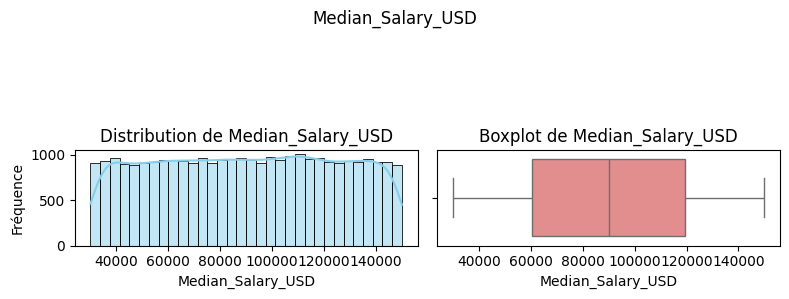

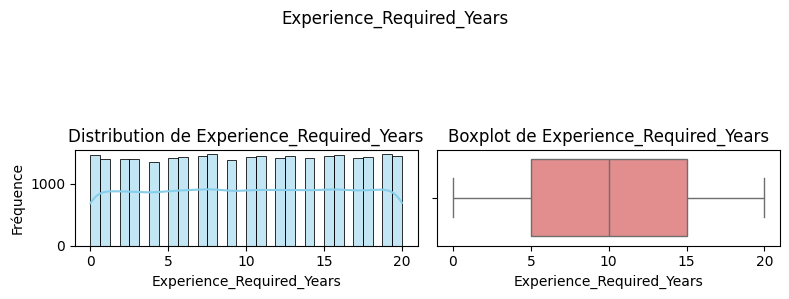

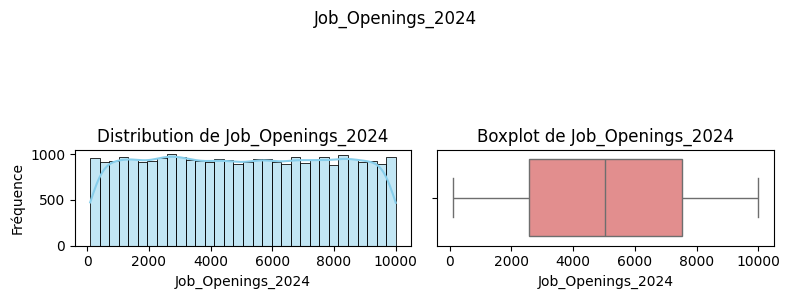

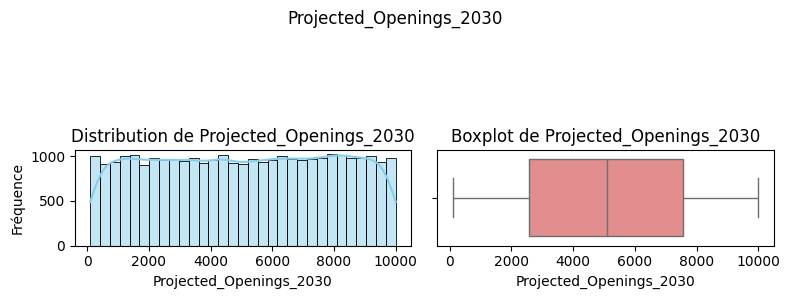

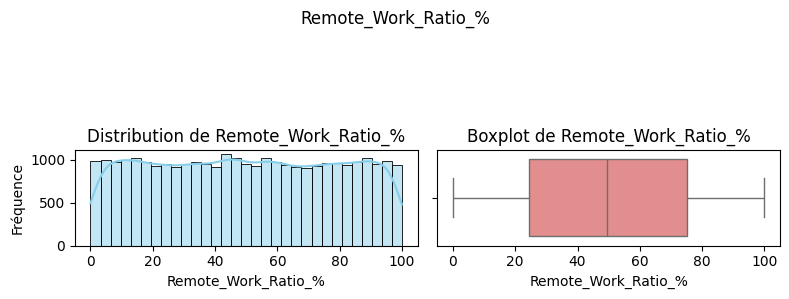

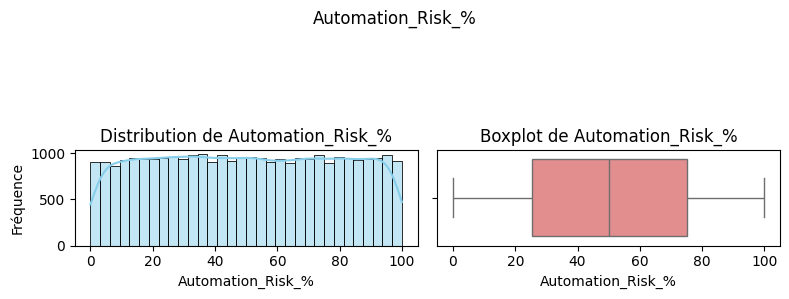

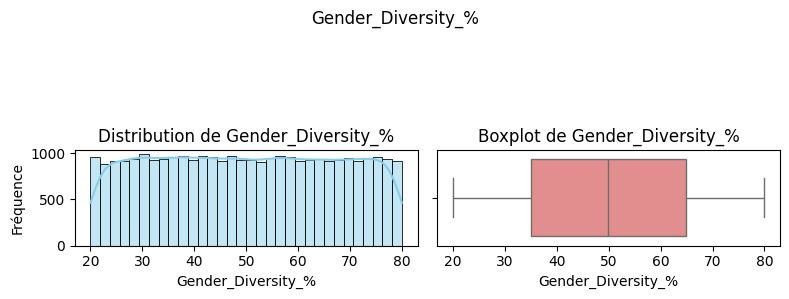

In [8]:
# --- Histogrammes + Boxplots pour variables numériques ---
for col in quantitative_cols:
    plt.figure(figsize=(8,3))
    plt.suptitle(f"{col}", fontsize=12)
    plt.subplot(1,2,1)
    # Histogramme
    sns.histplot(df[col], kde=True, color="skyblue")
    plt.title(f"Distribution de {col}")
    plt.xlabel(col)
    plt.ylabel("Fréquence")
    plt.tight_layout(rect=[0,0,1,0.75])
    # Boxplot
    plt.subplot(1,2,2)
    sns.boxplot(x=df[col], color='lightcoral')
    plt.title(f"Boxplot de {col}")
    plt.tight_layout(rect=[0,0,1,0.75])
    plt.show()

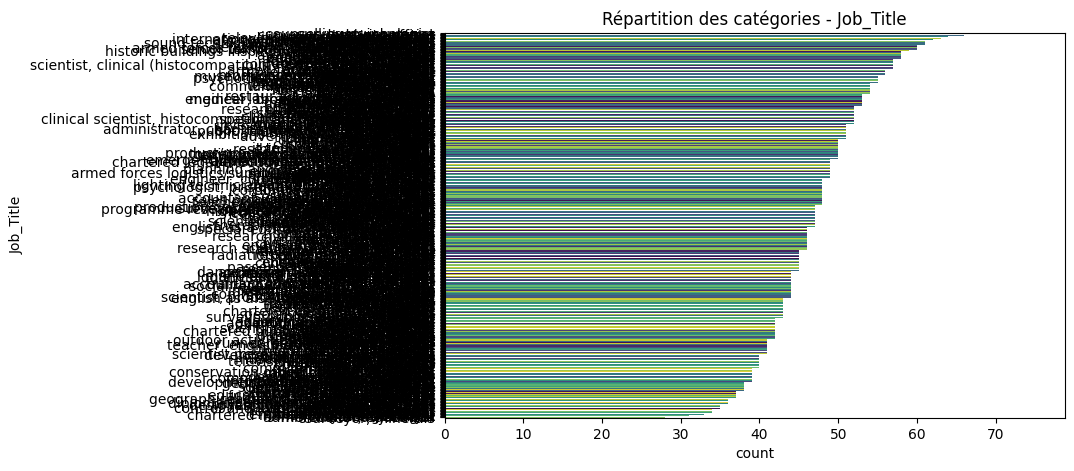

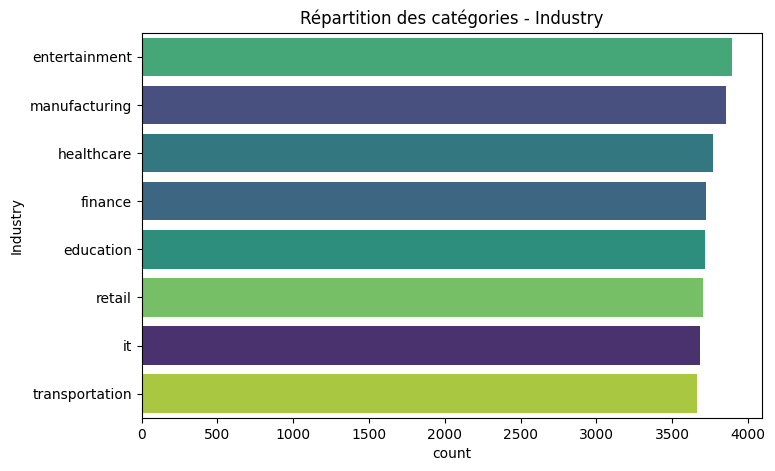

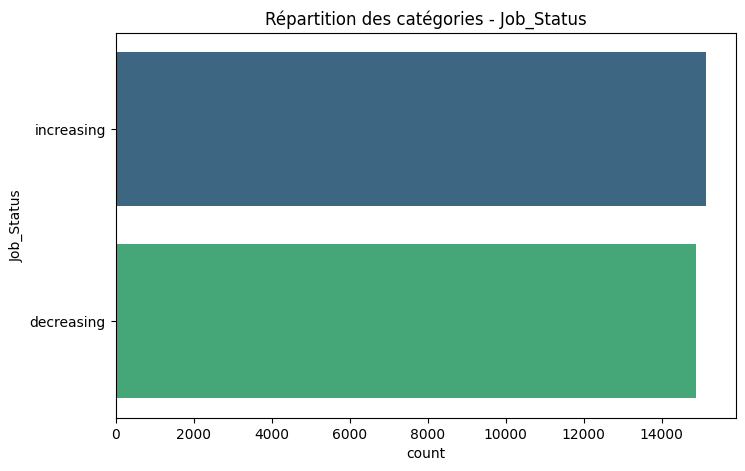

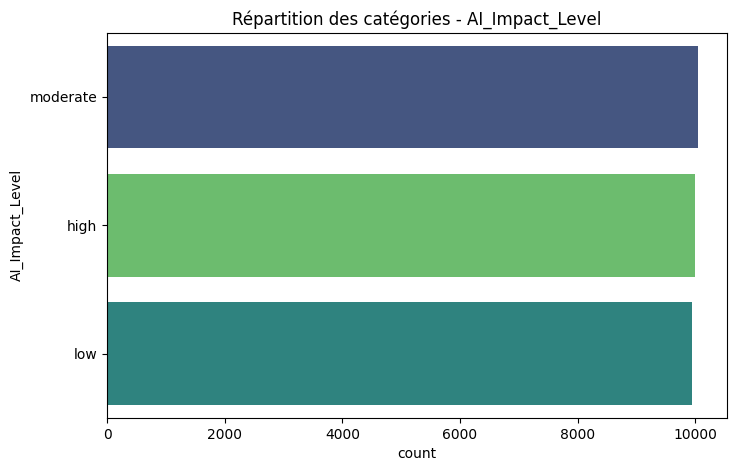

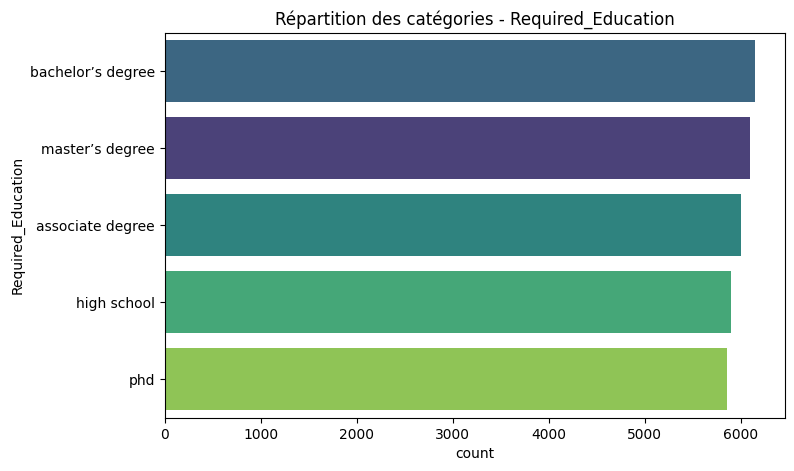

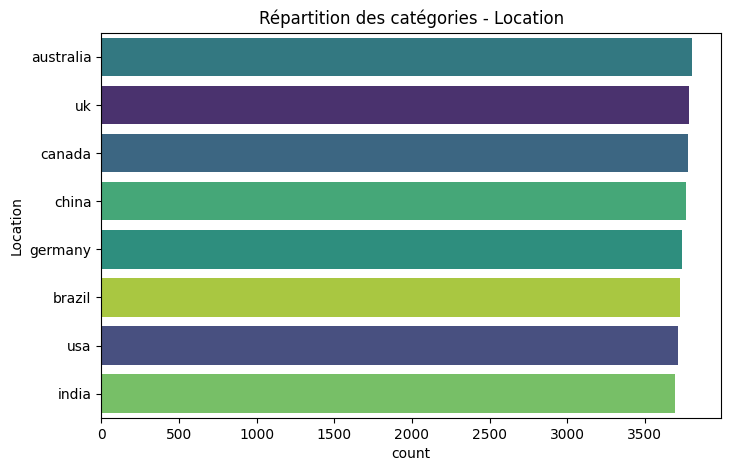

In [9]:
# --- Barplots pour variables catégorielles ---
for col in qualitative_cols:
    plt.figure(figsize=(8,5))
    sns.countplot(y=df[col], order=df[col].value_counts().index, hue=df[col],palette="viridis", legend=False)
    plt.title(f"Répartition des catégories - {col}")
    plt.show()

# **Qualité des données**

**Valeurs manquantes**

In [10]:
missing_count = df.isnull().sum()
missing_pct = (missing_count / len(df)) * 100
missing_summary = pd.DataFrame({
    'Valeurs manquantes': missing_count,
    '% manquantes': missing_pct.round(2)
})
display(missing_summary)

,Valeurs manquantes,% manquantes
Job_Title,0,0.0
Industry,0,0.0
Job_Status,0,0.0
AI_Impact_Level,0,0.0
Median_Salary_USD,0,0.0
Required_Education,0,0.0
Experience_Required_Years,0,0.0
Job_Openings_2024,0,0.0
Projected_Openings_2030,0,0.0
Remote_Work_Ratio_%,0,0.0


**Doublons et Valeurs uniques**

In [11]:
print("\nUnique values per column:")
print(df.nunique(dropna=False))
# Duplicate rows
duplicate_rows = df.duplicated().sum()
print(f"\nLignes dupliquées: {duplicate_rows}")


Unique values per column:
Job_Title                      639
Industry                         8
Job_Status                       2
AI_Impact_Level                  3
Median_Salary_USD            29968
Required_Education               5
Experience_Required_Years       21
Job_Openings_2024             9439
Projected_Openings_2030       9410
Remote_Work_Ratio_%           9466
Automation_Risk_%             9519
Location                         8
Gender_Diversity_%            5965
dtype: int64

Lignes dupliquées: 0


In [12]:
print("\nTop 5 valeurs les plus fréquentes (catégorielles) :")
for col in df.select_dtypes(include='object').columns:
    print(f"\n{col} :")
    print(df[col].value_counts(dropna=False).head())


Top 5 valeurs les plus fréquentes (catégorielles) :

Job_Title :
Job_Title
surveyor, insurance         75
counselling psychologist    70
charity officer             68
surveyor, land/geomatics    67
hydrogeologist              66
Name: count, dtype: int64

Industry :
Industry
entertainment    3895
manufacturing    3855
healthcare       3771
finance          3721
education        3714
Name: count, dtype: int64

Job_Status :
Job_Status
increasing    15136
decreasing    14864
Name: count, dtype: int64

AI_Impact_Level :
AI_Impact_Level
moderate    10042
high        10005
low          9953
Name: count, dtype: int64

Required_Education :
Required_Education
bachelor’s degree    6146
master’s degree      6097
associate degree     6003
high school          5900
phd                  5854
Name: count, dtype: int64

Location :
Location
australia    3802
uk           3784
canada       3775
china        3763
germany      3741
Name: count, dtype: int64


**VISUALISATIONS EXPLORATOIRES**

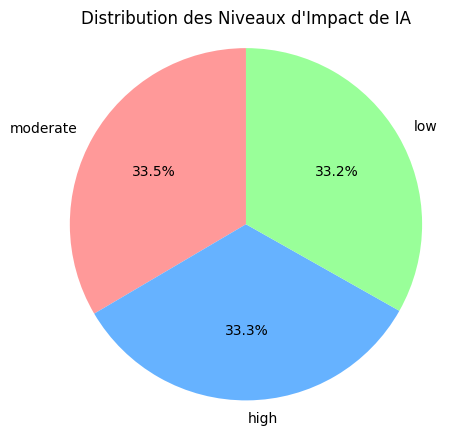

In [13]:
# Distribution des Niveaux d'Impact de l'IA
plt.figure(figsize=(5, 5))
ai_impact_counts = df['AI_Impact_Level'].value_counts()
plt.pie(ai_impact_counts, labels=ai_impact_counts.index, autopct='%1.1f%%', colors=['#FF9999', '#66B2FF', '#99FF99'], startangle=90)
plt.title('Distribution des Niveaux d\'Impact de IA')
plt.axis('equal')
plt.show()

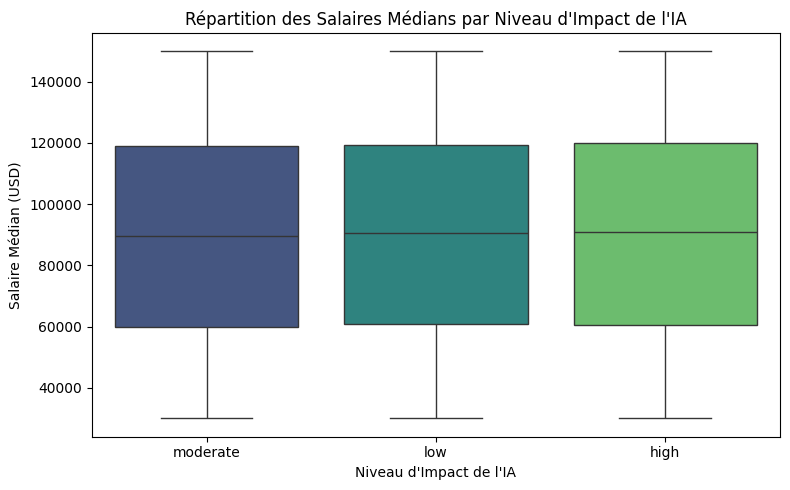

In [14]:
# Salaire médian par niveau d’impact de l’IA
plt.figure(figsize=(8, 5))
sns.boxplot(x='AI_Impact_Level', y='Median_Salary_USD', data=df, palette='viridis')
plt.title('Répartition des Salaires Médians par Niveau d\'Impact de l\'IA')
plt.xlabel('Niveau d\'Impact de l\'IA')
plt.ylabel('Salaire Médian (USD)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

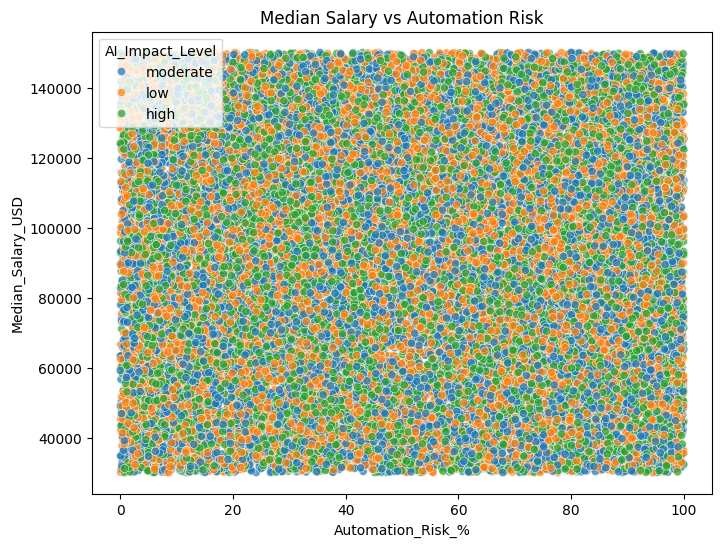

In [15]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Automation_Risk_%', y='Median_Salary_USD', hue='AI_Impact_Level', data=df, alpha=0.7)
plt.title("Median Salary vs Automation Risk")
plt.show()

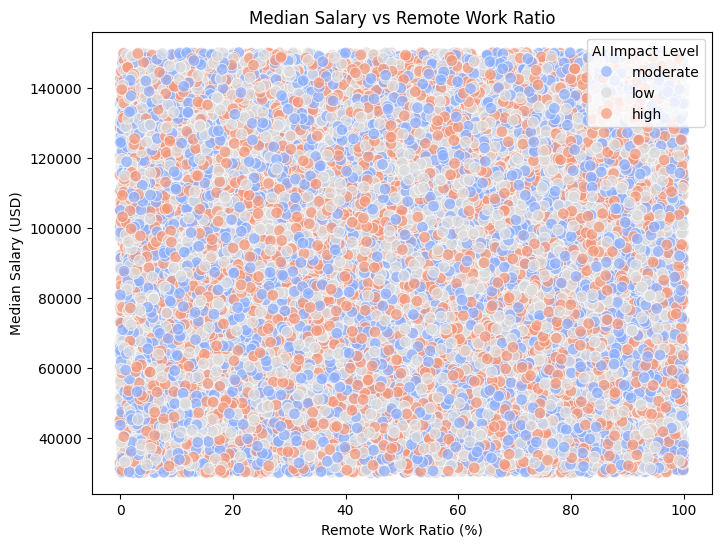

In [16]:
# Salaire vs Télétravail
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x="Remote_Work_Ratio_%",
    y="Median_Salary_USD",
    hue="AI_Impact_Level",
    palette="coolwarm",
    alpha=0.7, s=70
)
plt.title("Median Salary vs Remote Work Ratio")
plt.xlabel("Remote Work Ratio (%)")
plt.ylabel("Median Salary (USD)")
plt.legend(title="AI Impact Level")
plt.show()

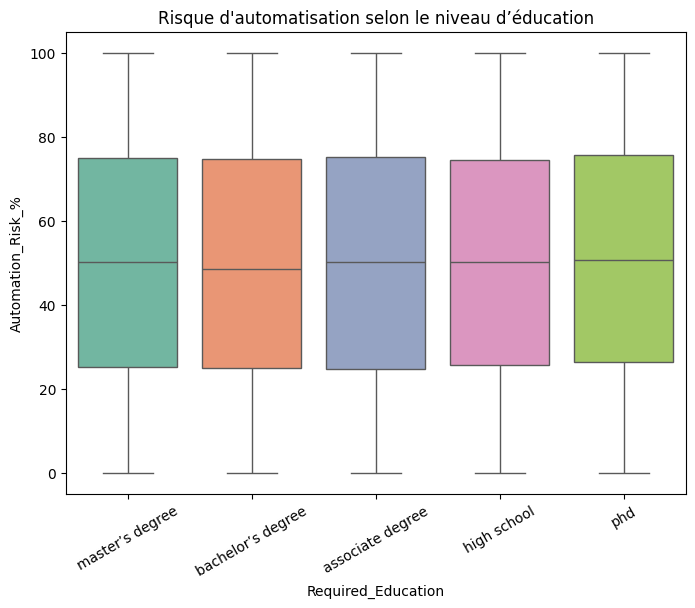

In [17]:
# Automatisation vs Éducation
plt.figure(figsize=(8,6))
sns.boxplot(
    data=df,
    x="Required_Education",
    y="Automation_Risk_%",
    palette="Set2"
)
plt.xticks(rotation=30)
plt.title("Risque d'automatisation selon le niveau d’éducation")
plt.xlabel("Required_Education")
plt.ylabel("Automation_Risk_%")
plt.show()

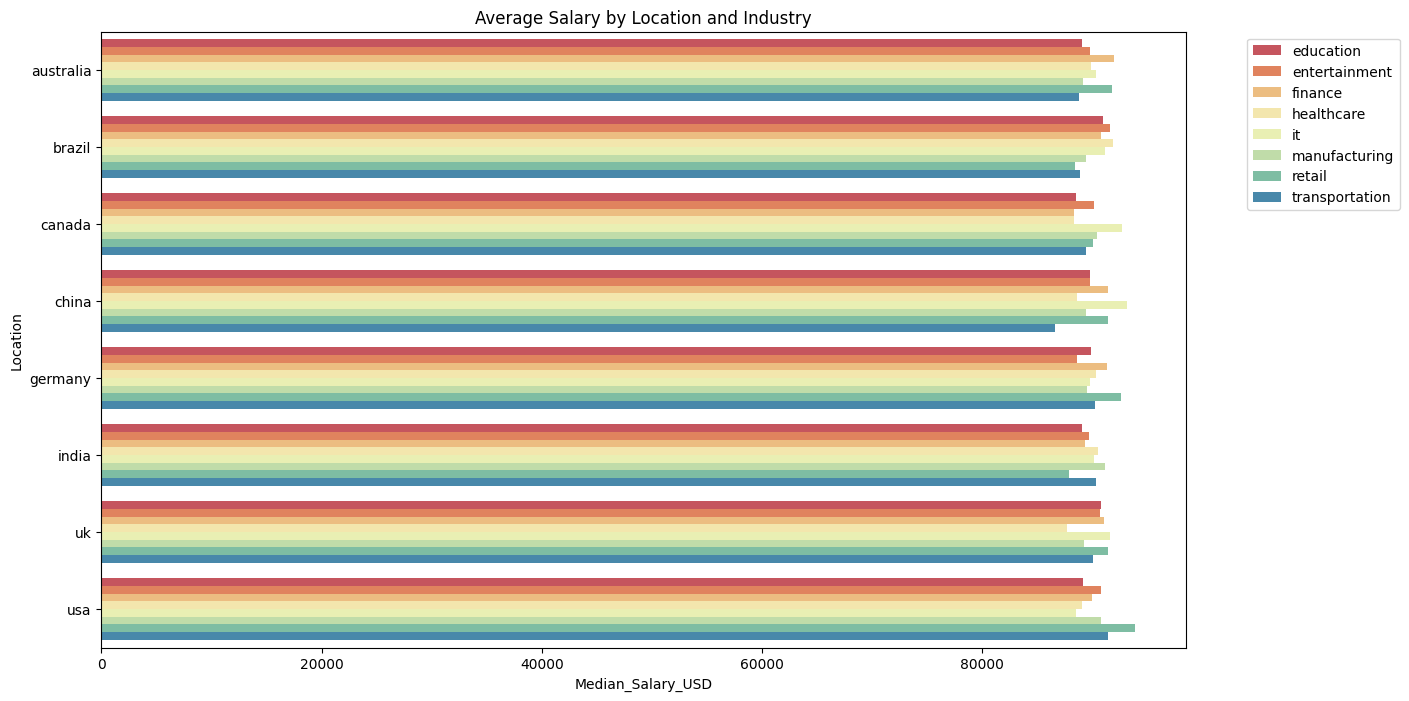

In [18]:
# Salaire moyen par pays et industrie
grouped = df.groupby(['Location', 'Industry'])['Median_Salary_USD'].mean().reset_index()
plt.figure(figsize=(14, 8))
sns.barplot(data=grouped, x='Median_Salary_USD', y='Location', hue='Industry', palette='Spectral')
plt.title("Average Salary by Location and Industry")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

**Matrice de corrélation**

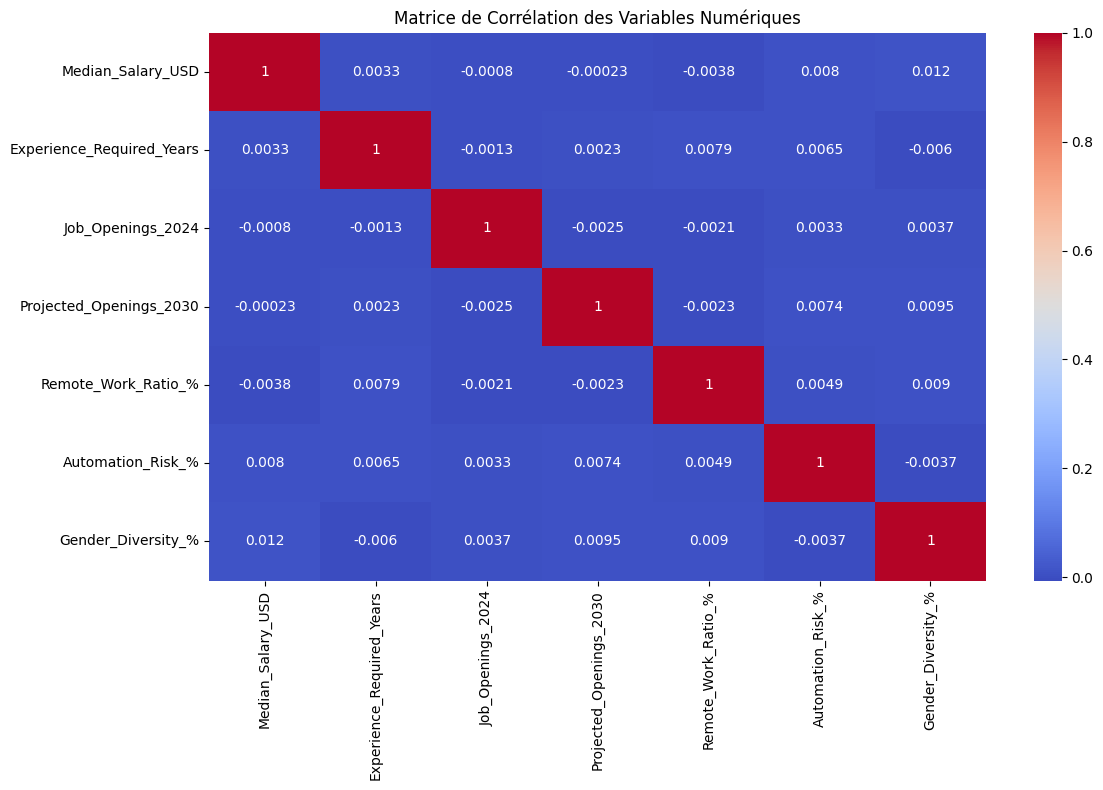

In [19]:
plt.figure(figsize=(12, 8))
correlation_matrix = df[quantitative_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Matrice de Corrélation des Variables Numériques')
plt.tight_layout()
plt.show()

# **DATA PREPARATION - NETTOYAGE ET PRÉPARATION**




> Pas de valeurs manquantes, ni doublons.
  Les outliers numériques sont traités par IQR capping (on réduit leur influence sans les supprimer).

> Nettoie les noms de colonnes : supprime espaces et parenthèses → pas de KeyError.
> Supprime les colonnes redondantes
> Crée une nouvelle feature : 
     Job_Growth_Rate_% = taux de croissance des jobs entre 2024 et 2030.
> Encodage One-Hot pour toutes les variables catégorielles.

> Standardisation des colonnes numériques (moyenne 0, écart-type 1).

> Retourne un DataFrame prêt pour PCA ou ML, sans erreur de nom de colonne.




***Nettoyage des données***

In [20]:
df.columns = (
    df.columns.str.strip().str.replace(" ", "_", regex=False).str.replace("(", "", regex=False).str.replace(")", "", regex=False))
for col in df.select_dtypes(include=['object']).columns:
        df[col] = (df[col].astype(str).str.lower().str.strip().str.replace("’", "'", regex=False) )    

In [21]:
#normalisation des noms de colonnes
df.columns = [c.strip().replace(" ", "_").replace("(", "").replace(")", "") for c in df.columns]
for col in df.select_dtypes('object'):
    df[col] = df[col].str.lower().str.strip()
# Pourcentage entre 0 et 100
percent_cols = ["Remote_Work_Ratio_%","Automation_Risk_%","Gender_Diversity_%"]
for col in percent_cols:
    df[col] = df[col].clip(lower=0, upper=100)

num_cols = df.select_dtypes(include=[np.number]).columns
# Aucune valeur négative dans les colonnes numériques
for col in num_cols:
    if (df[col] < 0).any():
        print(f"⚠️ Valeurs négatives détectées dans {col}")

**TRAITEMENT DES VALEURS MANQUANTES**

In [22]:
df_clean = df.copy()
missing_before = df_clean.isnull().sum()
print(f"Valeurs manquantes avant traitement:\n{missing_before[missing_before > 0]}")
# Vérification et traitement des valeurs manquantes
for col in df_clean.columns:
    if df_clean[col].isnull().sum() > 0:
        if df_clean[col].dtype in ['float64', 'int64']:
            # Pour les numériques: médiane (plus robuste aux outliers)
            df_clean[col].fillna(df_clean[col].median(), inplace=True)
        else:
            # Pour les catégorielles: mode ou 'unknown'
            df_clean[col].fillna(df_clean[col].mode()[0] if not df_clean[col].mode().empty else 'unknown', inplace=True)
            
# Traitement des doublons
print(f"Doublons avant suppression: {df_clean.duplicated().sum()}")
df_clean = df_clean.drop_duplicates()
print(f"Doublons après suppression: {df_clean.duplicated().sum()}")


Valeurs manquantes avant traitement:
Series([], dtype: int64)
Doublons avant suppression: 0
Doublons après suppression: 0


**TRAITEMENT DES VALEURS ABBERANTES**

In [23]:
def outliers_iqr(df, cols=None):
    df2 = df.copy()
    for col in cols:
        Q1 = df2[col].quantile(0.25)
        Q3 = df2[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df2[col] = np.where(df2[col] < lower, lower, df2[col])
        df2[col] = np.where(df2[col] > upper, upper, df2[col])
    return df2
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
df_clean = outliers_iqr(df_clean, cols=numeric_cols)
print("capped shape:", df_clean.shape)

capped shape: (30000, 13)


In [24]:
# Visualisation avant/après traitement des outliers
"""
for col in numeric_cols :
   if col in df_clean.columns:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7, 3))
        sns.boxplot(y=df[col], ax=ax1)
        ax1.set_title(f'Avant traitement - {col}')
        sns.boxplot(y=df_clean[col], ax=ax2)
        ax2.set_title(f'Après traitement - {col}')
        plt.tight_layout()
       plt.show()
"""

"\nfor col in numeric_cols :\n   if col in df_clean.columns:\n        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7, 3))\n        sns.boxplot(y=df[col], ax=ax1)\n        ax1.set_title(f'Avant traitement - {col}')\n        sns.boxplot(y=df_clean[col], ax=ax2)\n        ax2.set_title(f'Après traitement - {col}')\n        plt.tight_layout()\n       plt.show()\n"

**Feature engineering**

In [25]:
def feature_engineering(df):
    df_fe = df.copy()
    df_fe["Job_Growth_Rate_%"] = ((df_fe["Projected_Openings_2030"] - df_fe["Job_Openings_2024"]) 
                                  / df_fe["Job_Openings_2024"]) * 100
    df_fe['Job_Growth_Rate_%'] = df_fe['Job_Growth_Rate_%'].fillna(0)

    # Growth category
    df_fe['Growth_Category'] = pd.cut(
        df_fe['Job_Growth_Rate_%'],
        bins=[-float('inf'), -20, 20, float('inf')],
        labels=['decline', 'stable', 'growth']
    )
   # captures value of a job based on pay and stability. Salary adjusted by automation risk
    df_fe['Job_Value_Index'] = (df_fe['Median_Salary_USD'] - df_fe['Automation_Risk_%'] * 1000)
    
    # Captures risk of automation for jobs that cannot be done remotely.Automation risk for non-remote jobs
    df_fe['Vulnerability_Index'] = (df_fe['Automation_Risk_%'] *(100 - df_fe['Remote_Work_Ratio_%']) / 100)
  
    # Education -> numeric level
    education_map = {
        'high school': 1,
        'associate degree': 2,
        "bachelor's degree": 3,
        "master's degree": 4,
        'phd': 5
    }
    df_fe['Education_Level'] = df_fe['Required_Education'].map(education_map)
    
     
    columns_to_drop = [
        'Job_Openings_2024',
        'Projected_Openings_2030',
        'Required_Education'
        ]    
    df_fe = df_fe.drop(columns=[col for col in columns_to_drop if col in df_fe.columns])

    # Vérif cibles
    for col in ['Job_Status', 'Automation_Risk_%']:
        if col not in df_fe.columns:
            raise ValueError(f"{col} missing after feature engineering")

    # Remplir NaN des nouvelles features numériques
    numeric_cols_new = df_fe.select_dtypes(include=[np.number]).columns
    for col in numeric_cols_new:
        if df_fe[col].isnull().any():
            df_fe[col].fillna(df_fe[col].median(), inplace=True)

    return df_fe


df_engineered = feature_engineering(df_clean)
df_engineered = df_engineered.sample(n=10000, random_state=42)
df_engineered.to_csv("engineered_data.csv", index=False)

In [26]:
df_engineered.head(10)

,Job_Title,Industry,Job_Status,AI_Impact_Level,Median_Salary_USD,Experience_Required_Years,Remote_Work_Ratio_%,Automation_Risk_%,Location,Gender_Diversity_%,Job_Growth_Rate_%,Growth_Category,Job_Value_Index,Vulnerability_Index,Education_Level
2308,research scientist (life sciences),finance,decreasing,moderate,121278.59,0.0,67.12,30.65,canada,30.01,20.339679,growth,90628.59,10.077720,4
22404,tefl teacher,entertainment,increasing,moderate,118944.32,9.0,47.11,74.05,usa,58.02,1405.600000,growth,44894.32,39.165045,1
23397,"editor, magazine features",entertainment,increasing,low,95884.27,15.0,14.18,47.36,india,34.39,42.168675,growth,48524.27,40.644352,4
25058,"journalist, magazine",entertainment,increasing,low,139808.82,8.0,77.63,64.27,china,55.36,-11.636245,stable,75538.82,14.377199,3
2664,"engineer, land",transportation,increasing,low,51687.18,15.0,34.16,79.77,australia,25.64,74.302575,growth,-28082.82,52.520568,1
8511,software engineer,retail,increasing,low,142012.17,6.0,66.85,31.65,china,45.15,-73.710483,decline,110362.17,10.491975,3
5148,"journalist, magazine",retail,increasing,high,131878.57,15.0,35.64,71.15,usa,73.20,85.984848,growth,60728.57,45.792140,2
7790,administrator,finance,increasing,moderate,132462.80,6.0,45.87,21.38,uk,70.35,127.196765,growth,111082.80,11.572994,1
11311,telecommunications researcher,education,increasing,high,65471.32,11.0,79.90,32.62,canada,42.03,58.186101,growth,32851.32,6.556620,2
19043,"nurse, adult",manufacturing,decreasing,low,60548.87,16.0,96.89,1.07,germany,32.83,-89.169139,decline,59478.87,0.033277,5


In [27]:
df_encoded = df_engineered.copy()
categorical_cols = df_encoded.select_dtypes(include=['object']).columns.tolist()
cols_to_exclude = ['Job_Title', 'Job_Status']
cols_to_encode = [col for col in categorical_cols if col not in cols_to_exclude]
for col in cols_to_encode:
    le = LabelEncoder()
    df_encoded[col] = df_encoded[col].fillna('unknown')
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    print(f"Encoded column: {col}")
print(f"Encoded shape: {df_encoded.shape}")
df_encoded.head()

Encoded column: Industry
Encoded column: AI_Impact_Level
Encoded column: Location
Encoded shape: (10000, 15)


,Job_Title,Industry,Job_Status,AI_Impact_Level,Median_Salary_USD,Experience_Required_Years,Remote_Work_Ratio_%,Automation_Risk_%,Location,Gender_Diversity_%,Job_Growth_Rate_%,Growth_Category,Job_Value_Index,Vulnerability_Index,Education_Level
2308,research scientist (life sciences),2,decreasing,2,121278.59,0.0,67.12,30.65,2,30.01,20.339679,growth,90628.59,10.077720,4
22404,tefl teacher,1,increasing,2,118944.32,9.0,47.11,74.05,7,58.02,1405.600000,growth,44894.32,39.165045,1
23397,"editor, magazine features",1,increasing,1,95884.27,15.0,14.18,47.36,5,34.39,42.168675,growth,48524.27,40.644352,4
25058,"journalist, magazine",1,increasing,1,139808.82,8.0,77.63,64.27,3,55.36,-11.636245,stable,75538.82,14.377199,3
2664,"engineer, land",7,increasing,1,51687.18,15.0,34.16,79.77,0,25.64,74.302575,growth,-28082.82,52.520568,1


**Data Transformation**

In [28]:
def standardize_all(df):
    df_scaled = df.copy()
    numeric_cols = df_scaled.select_dtypes(include=[np.number]).columns.tolist()
    cols_to_exclude = ['Job_Status']
    numeric_cols_to_scale = [col for col in numeric_cols if col not in cols_to_exclude]
    print(f"Application de StandardScaler sur {len(numeric_cols)} colonnes numériques...")
    scaler = StandardScaler()
    df_scaled[numeric_cols_to_scale] = scaler.fit_transform(df_scaled[numeric_cols_to_scale])
    print("Standardisation terminée")
    return df_scaled, scaler
df_scaled, scaler = standardize_all(df_encoded)
X_scaled= df_scaled.select_dtypes(include=[np.number]).values

Application de StandardScaler sur 12 colonnes numériques...
Standardisation terminée


In [29]:
# Vérification de la normalisationP
print("\nVérification de la normalisation (premières 5 colonnes):")
for col in df_scaled.select_dtypes(include=[np.number]).columns[:5]:
    print(f"{col}: mean={df_scaled[col].mean():.3f}, std={df_scaled[col].std():.3f}")
df_scaled.shape


Vérification de la normalisation (premières 5 colonnes):
Industry: mean=0.000, std=1.000
AI_Impact_Level: mean=-0.000, std=1.000
Median_Salary_USD: mean=-0.000, std=1.000
Experience_Required_Years: mean=-0.000, std=1.000
Remote_Work_Ratio_%: mean=-0.000, std=1.000


(10000, 15)

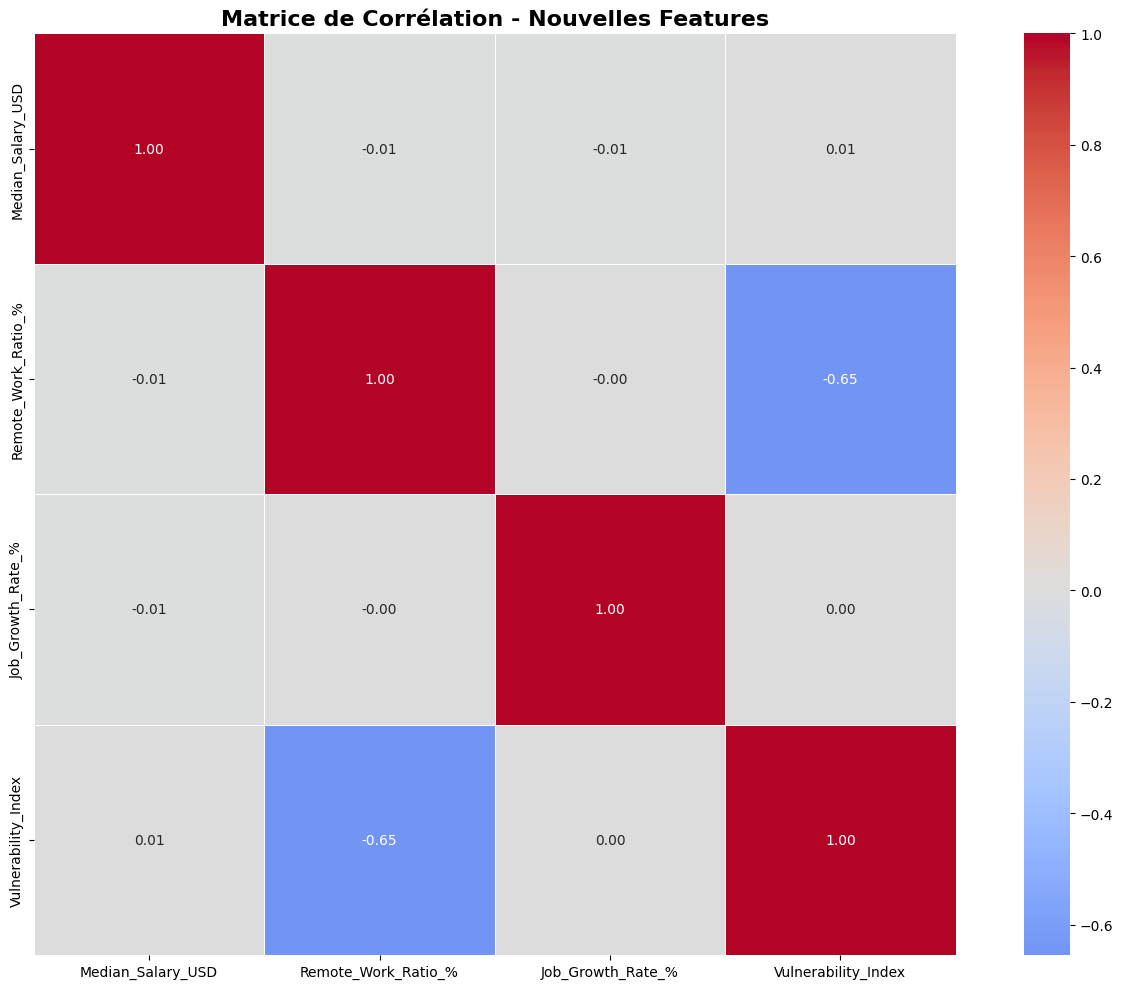


Corrélations fortes entre nouvelles features (|r| > 0.7):
  Aucune corrélation forte détectée (|r| > 0.7)

DISTRIBUTION DES NOUVELLES FEATURES


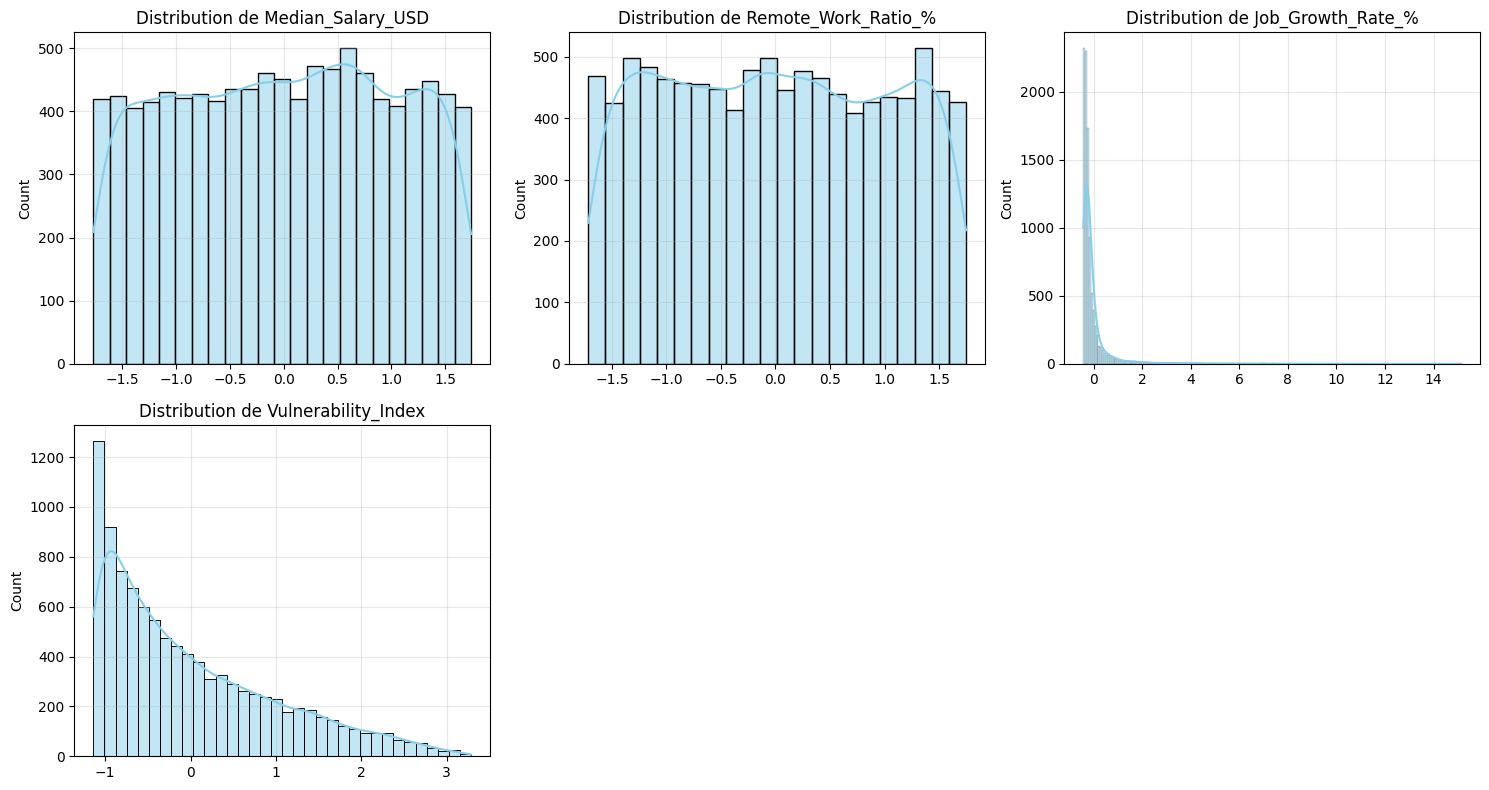

In [30]:
# Identifier les colonnes numériques (nouvelles features)
num_cols_new = df_scaled.select_dtypes(include=[np.number]).columns.tolist()

# Sélectionner les nouvelles features (exclure les encodages de texte)
new_feature_patterns = ['Salary', 'Flexibility', 'Qualification', 'Vulnerability', 
                        'Routine', 'Country_', 'Industry_', 'Growth', 'Ratio', 'Score']
new_features = [col for col in num_cols_new 
                if any(pattern.lower() in col.lower() for pattern in new_feature_patterns)]

if new_features:
    plt.figure(figsize=(14, 10))
    corr_matrix_new = df_scaled[new_features].corr()
    sns.heatmap(corr_matrix_new, annot=True, fmt=".2f", cmap="coolwarm", 
                center=0, square=True, linewidths=0.5)
    plt.title("Matrice de Corrélation - Nouvelles Features", fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Identifier les corrélations fortes
    print("\nCorrélations fortes entre nouvelles features (|r| > 0.7):")
    strong_corrs = []
    for i in range(len(corr_matrix_new.columns)):
        for j in range(i+1, len(corr_matrix_new.columns)):
            if abs(corr_matrix_new.iloc[i, j]) > 0.7:
                strong_corrs.append((
                    corr_matrix_new.columns[i],
                    corr_matrix_new.columns[j],
                    corr_matrix_new.iloc[i, j]
                ))
    
    if strong_corrs:
        for feat1, feat2, corr in strong_corrs:
            print(f"  {feat1} ↔ {feat2}: {corr:.3f}")
    else:
        print("  Aucune corrélation forte détectée (|r| > 0.7)")
else:
    print("Aucune nouvelle feature détectée pour la matrice de corrélation")

# Distribution des nouvelles features
print(f"\n{'='*50}")
print("DISTRIBUTION DES NOUVELLES FEATURES")
print(f"{'='*50}")

if new_features:
    n_cols = 3
    n_rows = int(np.ceil(len(new_features) / n_cols))
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
    axes = axes.flatten()
    
    for idx, feature in enumerate(new_features):
        ax = axes[idx]
        sns.histplot(df_scaled[feature], kde=True, ax=ax, color='skyblue')
        ax.set_title(f'Distribution de {feature}')
        ax.set_xlabel('')
        ax.grid(True, alpha=0.3)
    
    for idx in range(len(new_features), len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.show()

# **Sauvegarde des données préparées**

In [31]:
df_scaled.to_csv(OUTPUT_PREPARED_CSV, index=False)
print(f" Dataset préparé sauvegardé: {OUTPUT_PREPARED_CSV}")

print(f"\n RÉSUMÉ DU PIPELINE DE PRÉPARATION:")
print(f"Dataset original: {df.shape}")
print(f"Après nettoyage: {df_clean.shape}")
print(f"Après feature engineering: {df_engineered.shape}")
print(f"Après encodage: {df_encoded.shape}")
print(f"Après normalisation: {df_scaled.shape}")

print("\n Aperçu des données préparées:")
display(df_scaled.head(15))
df_scaled.columns

 Dataset préparé sauvegardé: prepared_data.csv

 RÉSUMÉ DU PIPELINE DE PRÉPARATION:
Dataset original: (30000, 13)
Après nettoyage: (30000, 13)
Après feature engineering: (10000, 15)
Après encodage: (10000, 15)
Après normalisation: (10000, 15)

 Aperçu des données préparées:


,Job_Title,Industry,Job_Status,AI_Impact_Level,Median_Salary_USD,Experience_Required_Years,Remote_Work_Ratio_%,Automation_Risk_%,Location,Gender_Diversity_%,Job_Growth_Rate_%,Growth_Category,Job_Value_Index,Vulnerability_Index,Education_Level
2308,research scientist (life sciences),-0.641440,decreasing,1.233380,0.900512,-1.655324,0.608707,-0.671108,-0.640489,-1.145717,-0.221243,growth,1.121629,-0.684853,0.721124
22404,tefl teacher,-1.078032,increasing,1.233380,0.832271,-0.166842,-0.084680,0.830288,1.532870,0.471521,2.162397,growth,0.099832,0.627804,-1.434703
23397,"editor, magazine features",-1.078032,increasing,0.011244,0.158126,0.825479,-1.225773,-0.093036,0.663526,-0.892825,-0.183681,growth,0.180932,0.694563,0.721124
25058,"journalist, magazine",-1.078032,increasing,0.011244,1.442231,-0.332229,0.972900,0.491955,-0.205817,0.317938,-0.276264,stable,0.784493,-0.490826,0.002515
2664,"engineer, land",1.541518,increasing,0.011244,-1.133946,0.825479,-0.533425,1.028168,-1.509832,-1.398032,-0.128388,growth,-1.530627,1.230514,-1.434703
8511,software engineer,1.104926,increasing,0.011244,1.506644,-0.663003,0.599351,-0.636514,-0.205817,-0.271566,-0.383077,decline,1.562518,-0.666159,0.002515
5148,"journalist, magazine",1.104926,increasing,-1.210893,1.210395,0.825479,-0.482140,0.729964,1.532870,1.347982,-0.108286,growth,0.453601,0.926873,-0.716094
7790,administrator,-0.641440,increasing,1.233380,1.227475,-0.663003,-0.127649,-0.991798,1.098198,1.183429,-0.037372,growth,1.578618,-0.617374,-1.434703
11311,telecommunications researcher,-1.514624,increasing,-1.210893,-0.730976,0.163931,1.051560,-0.602958,-0.640489,-0.451708,-0.156120,growth,-0.169234,-0.843754,-0.716094
19043,"nurse, adult",0.668335,decreasing,0.011244,-0.874880,0.990866,1.640299,-1.694410,0.228855,-0.982897,-0.409677,decline,0.425680,-1.138141,1.439733


Index(['Job_Title', 'Industry', 'Job_Status', 'AI_Impact_Level',
       'Median_Salary_USD', 'Experience_Required_Years', 'Remote_Work_Ratio_%',
       'Automation_Risk_%', 'Location', 'Gender_Diversity_%',
       'Job_Growth_Rate_%', 'Growth_Category', 'Job_Value_Index',
       'Vulnerability_Index', 'Education_Level'],
      dtype='object')

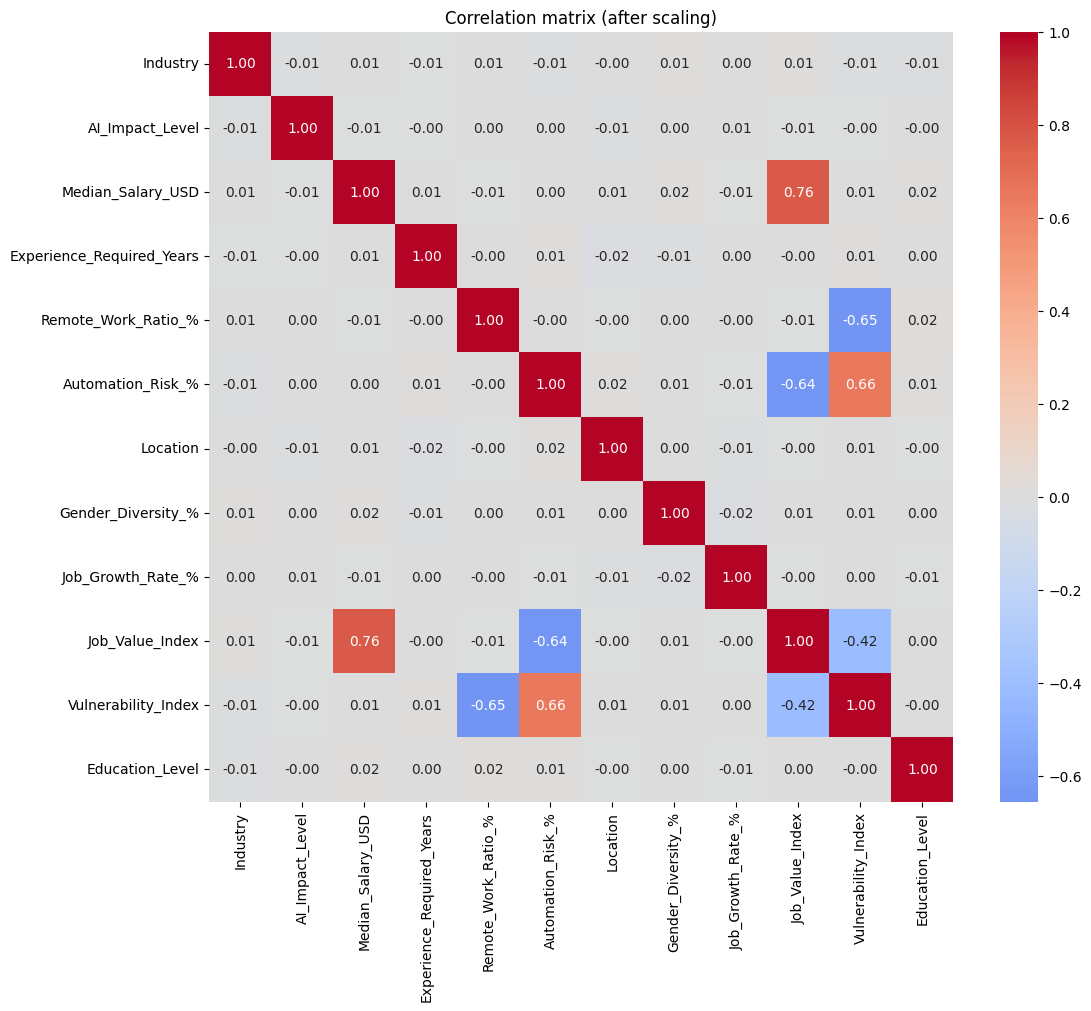

In [32]:
# 2) Correlation heatmap (scaled numeric features)
num_cols_scaled = df_scaled.select_dtypes(include=[np.number]).columns.tolist()
plt.figure(figsize=(12,10))
corr = df_scaled[num_cols_scaled].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation matrix (after scaling)")
plt.show()

# **PCA**

**PCA INITIALIZATION AND DATA PREP**

In [33]:
numerical_cols = df_scaled.select_dtypes(include=[np.number]).columns.tolist()
X = df_scaled[numerical_cols].copy()
feature_names = X.columns.tolist()  
print(f"Données PCA: {X.shape} - {len(feature_names)} variables numériques")
print(f"Variables utilisées: {feature_names}")

Données PCA: (10000, 12) - 12 variables numériques
Variables utilisées: ['Industry', 'AI_Impact_Level', 'Median_Salary_USD', 'Experience_Required_Years', 'Remote_Work_Ratio_%', 'Automation_Risk_%', 'Location', 'Gender_Diversity_%', 'Job_Growth_Rate_%', 'Job_Value_Index', 'Vulnerability_Index', 'Education_Level']


In [34]:
pca = PCA(n_components=0.85) 
X_pca = pca.fit_transform(X)
explained_ratio = pca.explained_variance_ratio_
eigenvalues = pca.explained_variance_
cumulative_variance= np.cumsum(explained_ratio)

In [35]:
n_components_display = min(10, len(eigenvalues))
full_variance_summary = pd.DataFrame({
    "PC": [f"PC{i+1}" for i in range(n_components_display)],
    "Eigenvalue": np.round(eigenvalues[:n_components_display], 4),
    "% Variance": np.round(explained_ratio[:n_components_display] * 100, 2),
    "% Cumulative": np.round(cumulative_variance[:n_components_display] * 100, 2)
})
print(full_variance_summary.to_string(index=False))

print(f"\n PCA OPTIMIZED: {pca.n_components_} components explain {cumulative_variance[-1]:.1%} variance")
print(f"PC1 strength: {explained_ratio[0]:.1%}")

 PC  Eigenvalue  % Variance  % Cumulative
PC1      2.3881       19.90         19.90
PC2      1.5406       12.84         32.74
PC3      1.0457        8.71         41.45
PC4      1.0295        8.58         50.03
PC5      1.0094        8.41         58.44
PC6      1.0059        8.38         66.82
PC7      0.9921        8.27         75.09
PC8      0.9819        8.18         83.27
PC9      0.9734        8.11         91.38

 PCA OPTIMIZED: 9 components explain 91.4% variance
PC1 strength: 19.9%


PCA WITH DIFFERENT VARIANCE THRESHOLDS

In [36]:
# CRITÈRES DE SÉLECTION
n_kaiser = int((eigenvalues > 1).sum())
n_85 = pca.n_components_  # Now we know exactly how many for 85%

print(f"\nCRITÈRES DE SÉLECTION:")
print(f"   Kaiser (λ > 1):     {n_kaiser} composantes")
print(f"   85% variance:       {n_85} composantes")
# Recommandation finale
recommended = n_85  # Use the 85% variance components
print(f"\n RECOMMANDATION: {recommended} composantes")
print(f"   Variance conservée: {cumulative_variance[recommended-1]*100:.2f}%")
print(f"   Réduction: {X.shape[1]} → {recommended} variables")


CRITÈRES DE SÉLECTION:
   Kaiser (λ > 1):     6 composantes
   85% variance:       9 composantes

 RECOMMANDATION: 9 composantes
   Variance conservée: 91.38%
   Réduction: 12 → 9 variables


In [37]:
# Qualité de la PCA
print(f"\nQUALITÉ DE LA PCA:")
if explained_ratio[0] > 0.15:
    print(f"    EXCELLENTE - PC1 capture >15% variance")
elif explained_ratio[0] > 0.10:
    print(f"    BONNE - PC1 capture >10% variance")
elif explained_ratio[0] > 0.07:
    print(f"    MOYENNE - PC1 capture seulement {explained_ratio[0]*100:.1f}%")
else:
    print(f"    FAIBLE - PC1 capture <7% variance")

if cumulative_variance[1] > 0.30:
    print(f"    BONNE structure 2D - {cumulative_variance[1]*100:.1f}% sur 2 axes")
elif cumulative_variance[1] > 0.20:
    print(f"    Structure 2D acceptable - {cumulative_variance[1]*100:.1f}%")
else:
    print(f"    Structure 2D faible - seulement {cumulative_variance[1]*100:.1f}%")


QUALITÉ DE LA PCA:
    EXCELLENTE - PC1 capture >15% variance
    BONNE structure 2D - 32.7% sur 2 axes


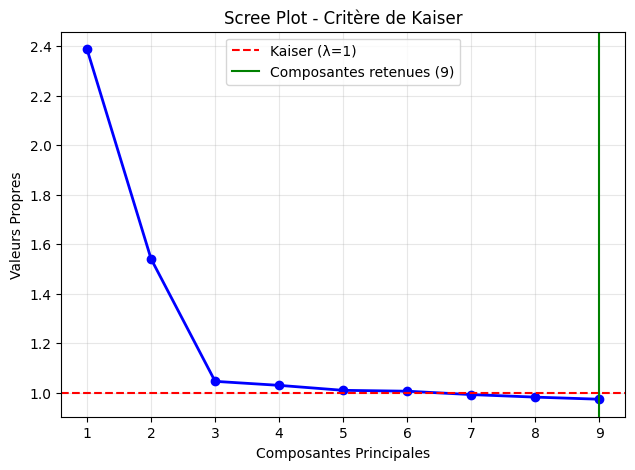

In [38]:
# VISUALISATION DES CRITÈRES
plt.figure(figsize=(16, 5))
# Scree Plot
plt.subplot(1, 2, 1)
components_range = range(1, len(eigenvalues) + 1)
plt.plot(components_range, eigenvalues, 'bo-', linewidth=2, markersize=6)
plt.axhline(y=1, color='red', linestyle='--', label='Kaiser (λ=1)')
plt.axvline(x=recommended, color='green', linestyle='-', 
            label=f'Composantes retenues ({recommended})')
plt.xlabel('Composantes Principales')
plt.ylabel('Valeurs Propres')
plt.title('Scree Plot - Critère de Kaiser')
plt.legend()
plt.grid(True, alpha=0.3)

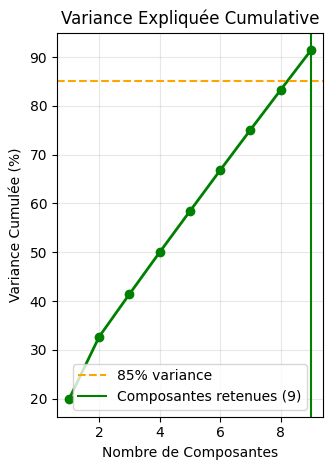

In [39]:
# Variance Cumulée
plt.subplot(1, 2, 2)
plt.plot(components_range, cumulative_variance * 100, 'go-', linewidth=2, markersize=6)
plt.axhline(y=85, color='orange', linestyle='--', label='85% variance')
plt.axvline(x=recommended, color='green', linestyle='-', 
            label=f'Composantes retenues ({recommended})')
plt.xlabel('Nombre de Composantes')
plt.ylabel('Variance Cumulée (%)')
plt.title('Variance Expliquée Cumulative')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

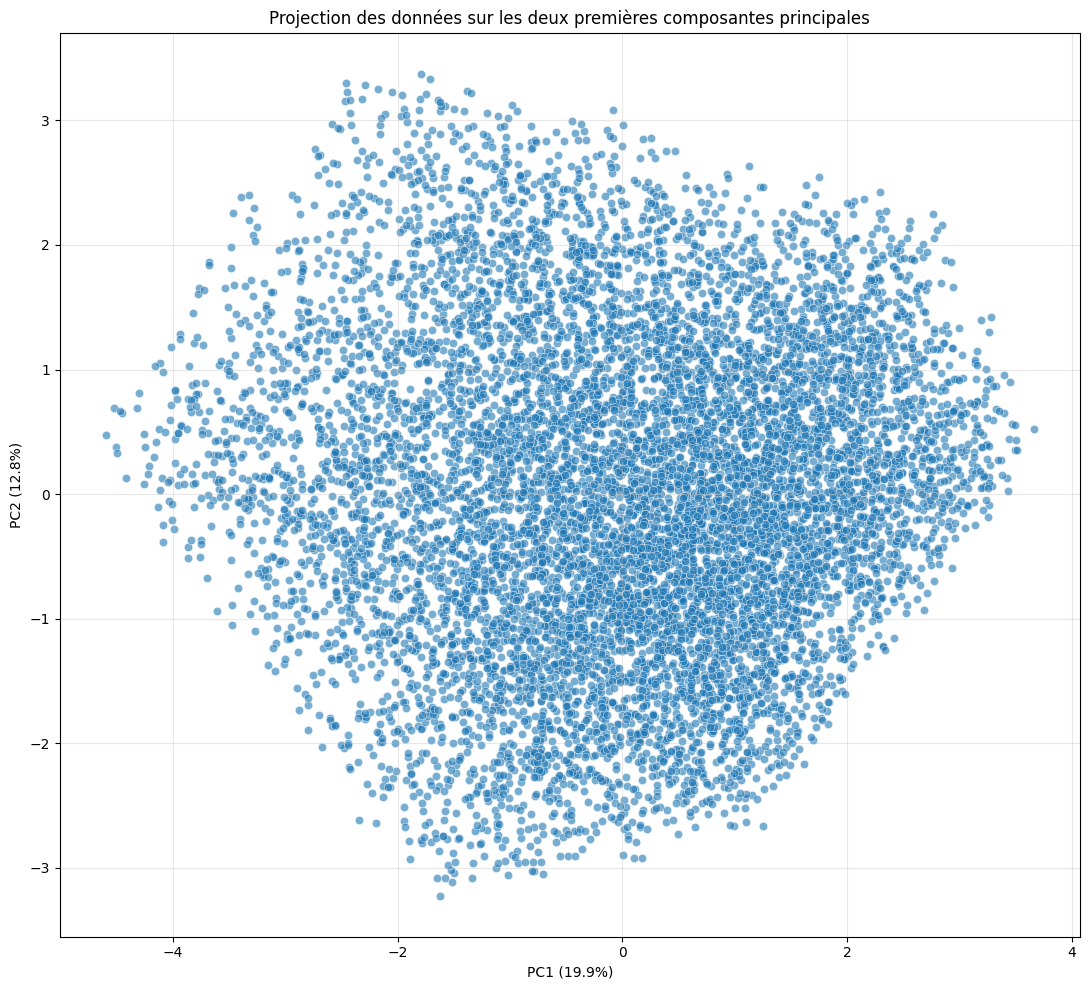

In [40]:
# PROJECTION PC1-PC2
pca_df = pd.DataFrame(X_pca[:, :2], columns=['PC1', 'PC2'])
plt.figure(figsize=(11, 10))
sns.scatterplot(x='PC1', y='PC2', data=pca_df, alpha=0.6)
plt.title('Projection des données sur les deux premières composantes principales')
plt.xlabel(f'PC1 ({explained_ratio[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({explained_ratio[1]*100:.1f}%)')
plt.grid(True, alpha=0.3)
 
plt.tight_layout()
plt.show()

In [41]:
# ANALYSE DES COMPOSANTES PRINCIPALES
loadings = pca.components_.T * np.sqrt(eigenvalues)
loadings_df = pd.DataFrame(loadings, index=feature_names, 
                          columns=[f'PC{i+1}' for i in range(loadings.shape[1])])

print("TOP VARIABLES PER COMPONENT:")
for i in range(4):  # First 4 components
    # Get top 3 variables for this component
    top_vars = loadings_df.iloc[:, i].abs().sort_values(ascending=False).head(3)
    
    print(f"\nPC{i+1} ({explained_ratio[i]*100:.1f}% variance):")
    for var, loading in top_vars.items():
        direction = "POSITIVE" if loadings_df.loc[var, f'PC{i+1}'] > 0 else "NEGATIVE"
        print(f"   {var}: {abs(loading):.3f} ({direction})")

TOP VARIABLES PER COMPONENT:

PC1 (19.9% variance):
   Job_Value_Index: 0.867 (POSITIVE)
   Vulnerability_Index: 0.809 (NEGATIVE)
   Automation_Risk_%: 0.785 (NEGATIVE)

PC2 (12.8% variance):
   Median_Salary_USD: 0.717 (POSITIVE)
   Remote_Work_Ratio_%: 0.684 (NEGATIVE)
   Vulnerability_Index: 0.552 (POSITIVE)

PC3 (8.7% variance):
   Gender_Diversity_%: 0.494 (POSITIVE)
   Job_Growth_Rate_%: 0.480 (NEGATIVE)
   Education_Level: 0.362 (POSITIVE)

PC4 (8.6% variance):
   Education_Level: 0.544 (POSITIVE)
   Experience_Required_Years: 0.536 (POSITIVE)
   Industry: 0.380 (NEGATIVE)


# CERCLE DES CORRÉLATIONS


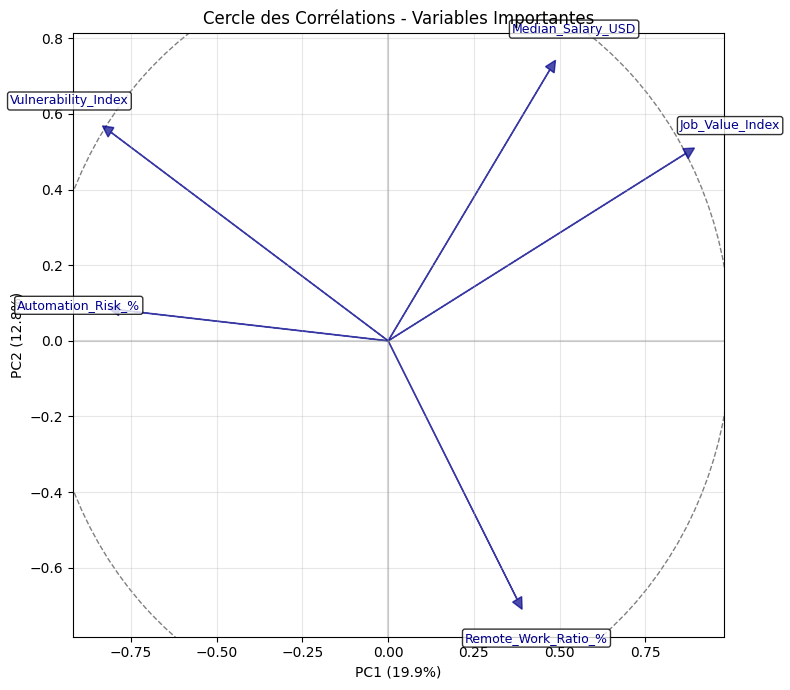

In [42]:


plt.figure(figsize=(8, 7))

# Création du cercle unitaire
circle = plt.Circle((0, 0), 1, color='gray', fill=False, linestyle='--')
plt.gca().add_artist(circle)

# Axes centraux
plt.axhline(y=0, color='grey', linestyle='-', alpha=0.3)
plt.axvline(x=0, color='grey', linestyle='-', alpha=0.3)

# Sélection des variables importantes (contribution > 0.3)
important_vars = []
for i, var_name in enumerate(feature_names):
    contribution = np.sqrt(loadings[i, 0]**2 + loadings[i, 1]**2)
    if contribution > 0.3:
        important_vars.append((var_name, loadings[i, 0], loadings[i, 1], contribution))

# Tri par contribution
important_vars.sort(key=lambda x: x[3], reverse=True)

# Affichage des top 8 variables (pour la lisibilité)
for var_name, x, y, contribution in important_vars[:8]:
    plt.arrow(0, 0, x, y, head_width=0.03, head_length=0.03, 
              fc='darkblue', ec='darkblue', alpha=0.7)
    plt.text(x * 1.15, y * 1.15, var_name, fontsize=9, 
             ha='center', va='center', color='darkblue',
             bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.8))

 
plt.xlabel(f'PC1 ({explained_ratio[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({explained_ratio[1]*100:.1f}%)')
plt.title('Cercle des Corrélations - Variables Importantes')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [43]:
print("\n🎯 TOP 10 VARIABLES LES PLUS IMPORTANTES:")
for var_name, x, y, contribution in important_vars[:10]:
    print(f"• {var_name}: contribution={contribution:.3f}")



🎯 TOP 10 VARIABLES LES PLUS IMPORTANTES:
• Job_Value_Index: contribution=0.999
• Vulnerability_Index: contribution=0.979
• Median_Salary_USD: contribution=0.858
• Automation_Risk_%: contribution=0.789
• Remote_Work_Ratio_%: contribution=0.780


# CARTE DES INDIVIDUS


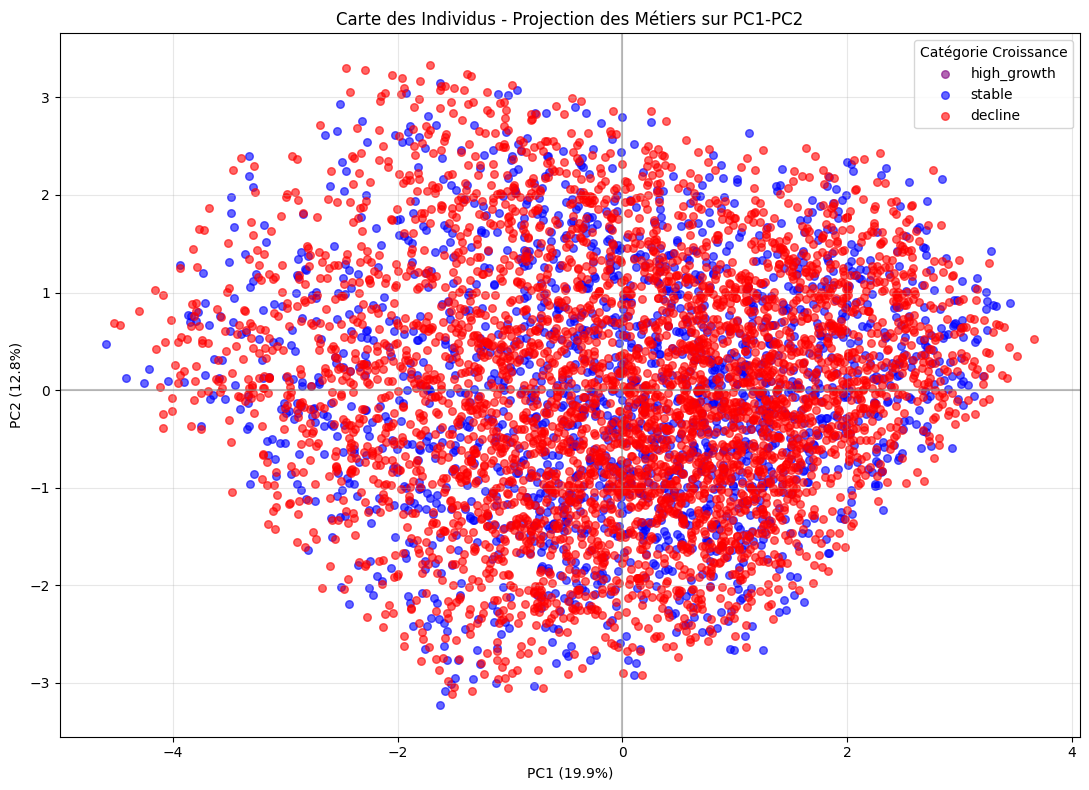

In [44]:
individuals_df = pd.DataFrame({
    'PC1': X_pca[:, 0],  'PC2': X_pca[:, 1]
})
# Ajout des métadonnées pour l'interprétation
if 'Growth_Category' in df_engineered.columns:
    individuals_df['growth_category'] = df_engineered['Growth_Category'].values

if 'AI_Impact_Level' in df_engineered.columns:
    individuals_df['ai_impact'] = df_engineered['AI_Impact_Level'].values

plt.figure(figsize=(11, 8))
if 'growth_category' in individuals_df.columns:
    colors = {'high_growth': 'purple', 'stable': 'blue', 'decline': 'red' }
    for category, color in colors.items():
        mask = individuals_df['growth_category'] == category
        plt.scatter(individuals_df.loc[mask, 'PC1'], 
                   individuals_df.loc[mask, 'PC2'], 
                   c=color, label=category, alpha=0.6, s=30)   
    plt.legend(title='Catégorie Croissance')
else:
    plt.scatter(individuals_df['PC1'], individuals_df['PC2'], alpha=0.6, s=30)

plt.axhline(y=0, color='gray', linestyle='-', alpha=0.5)
plt.axvline(x=0, color='gray', linestyle='-', alpha=0.5)
plt.xlabel(f'PC1 ({explained_ratio[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({explained_ratio[1]*100:.1f}%)')
plt.title('Carte des Individus - Projection des Métiers sur PC1-PC2')
plt.grid(True, alpha=0.3)
 
plt.tight_layout()
plt.show()

# superposition

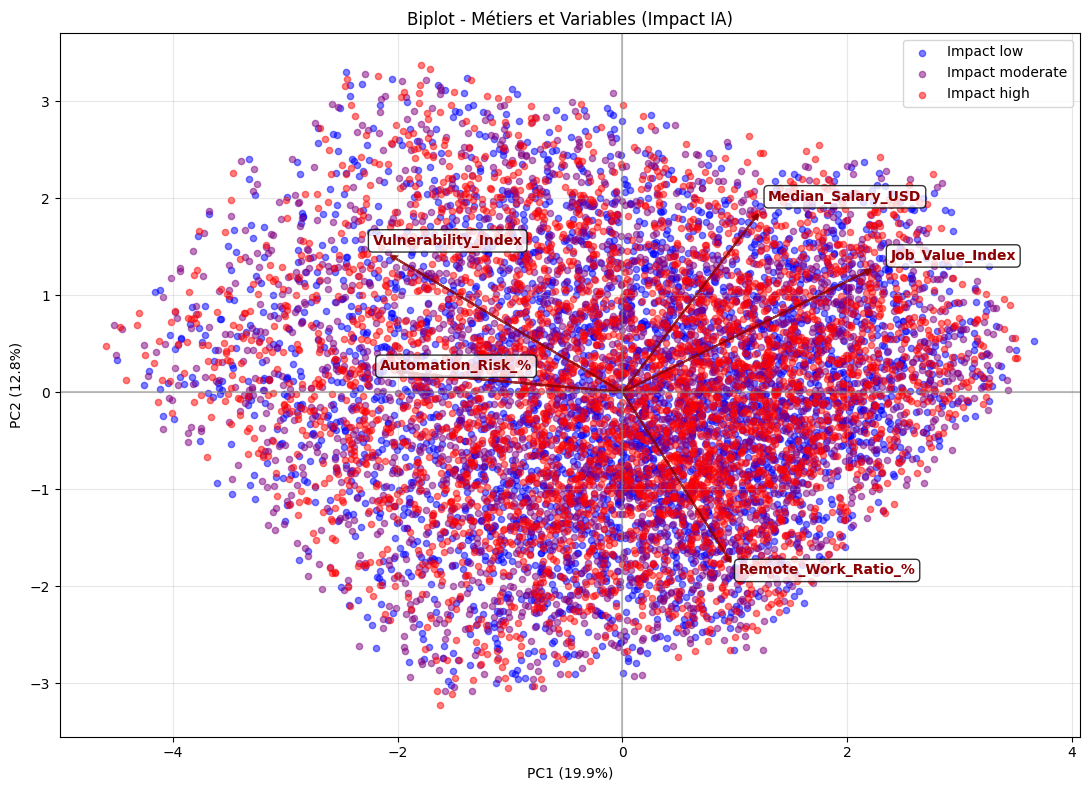

In [45]:
plt.figure(figsize=(11, 8))
# Individus colorés par impact IA
if 'ai_impact' in individuals_df.columns:
    impact_colors = {'low': 'blue', 'moderate': 'purple', 'high': 'red'}
    
    for impact_level, color in impact_colors.items():
        mask = individuals_df['ai_impact'] == impact_level
        plt.scatter(individuals_df.loc[mask, 'PC1'], 
                   individuals_df.loc[mask, 'PC2'], 
                   c=color, label=f'Impact {impact_level}', alpha=0.5, s=20)
else:
    plt.scatter(individuals_df['PC1'], individuals_df['PC2'], alpha=0.5, s=20, color='lightblue')

# Vecteurs variables (échelle adaptée)
scale = 2.5
significant_vars = important_vars[:6]  

for var_name, x, y, contribution in significant_vars:
    plt.arrow(0, 0, x * scale, y * scale, 
              head_width=0.05, head_length=0.05, 
              fc='darkred', ec='darkred', alpha=0.8, linewidth=1.5)
    plt.text(x * scale * 1.1, y * scale * 1.1, var_name, 
             fontsize=10, color='darkred', weight='bold',
             bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

plt.axhline(y=0, color='gray', linestyle='-', alpha=0.5)
plt.axvline(x=0, color='gray', linestyle='-', alpha=0.5)
plt.xlabel(f'PC1 ({explained_ratio[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({explained_ratio[1]*100:.1f}%)')
plt.title('Biplot - Métiers et Variables (Impact IA)')
plt.legend()
plt.grid(True, alpha=0.3)
 
plt.tight_layout()
plt.show()

In [46]:
# INTERPRÉTATION
print(f""" INTERPRÉTATION DES 2 PREMIÈRES COMPOSANTES PRINCIPALES:
COMPOSANTE PRINCIPALE 1 ({explained_ratio[0]*100:.1f}% de variance):
• Variable la plus importante: {loadings_df['PC1'].abs().idxmax()}
• Signification: {loadings_df['PC1'].abs().idxmax().replace('_', ' ').title()}

COMPOSANTE PRINCIPALE 2 ({explained_ratio[1]*100:.1f}% de variance):
• Variable la plus importante: {loadings_df['PC2'].abs().idxmax()}
• Signification: {loadings_df['PC2'].abs().idxmax().replace('_', ' ').title()}

QUALITÉ DE LA RÉDUCTION:
• 2 premières composantes: {cumulative_variance[1]:.1%} de variance totale
• {recommended} composantes recommandées: {cumulative_variance[recommended-1]:.1%} de variance
• Réduction dimensionnelle: {X.shape[1]} → {recommended} variables
• Critères utilisés: Kaiser + 85% variance
""")


 INTERPRÉTATION DES 2 PREMIÈRES COMPOSANTES PRINCIPALES:
COMPOSANTE PRINCIPALE 1 (19.9% de variance):
• Variable la plus importante: Job_Value_Index
• Signification: Job Value Index

COMPOSANTE PRINCIPALE 2 (12.8% de variance):
• Variable la plus importante: Median_Salary_USD
• Signification: Median Salary Usd

QUALITÉ DE LA RÉDUCTION:
• 2 premières composantes: 32.7% de variance totale
• 9 composantes recommandées: 91.4% de variance
• Réduction dimensionnelle: 12 → 9 variables
• Critères utilisés: Kaiser + 85% variance



In [47]:

# Select recommended components (should be 7 with the 85% variance PCA)
recommended = n_85  # Use the 85% variance components
X_reduced = X_pca[:, :recommended]

# Create final dataset
reduced_columns = [f'PC{i+1}' for i in range(recommended)]
dataset_reduit = pd.DataFrame(X_reduced, columns=reduced_columns)

# Add essential metadata for clustering interpretation
clustering_metadata = ['Job_Title', 'AI_Impact_Level', 'Industry', 'Location']
for col in clustering_metadata:
    if col in df_engineered.columns:
        dataset_reduit[col] = df_engineered[col].values

print(f"Dimensions: {dataset_reduit.shape}")
print(f"PCA Components: {recommended}")
print(f"Variance retained: {cumulative_variance[recommended-1]*100:.1f}%")
dataset_reduit.to_csv(OUTPUT_PCA_CSV, index=False)
print(f" Dataset réduit sauvegardé: {OUTPUT_PCA_CSV}")
dataset_reduit.head(5)

Dimensions: (10000, 13)
PCA Components: 9
Variance retained: 91.4%
 Dataset réduit sauvegardé: dataset_reduit.csv


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,Job_Title,AI_Impact_Level,Industry,Location
0,1.755449,0.183078,-0.196943,0.464800,0.788649,-1.674662,0.354047,0.922805,-0.976561,research scientist (life sciences),moderate,finance,canada
1,-0.506084,0.888199,-0.735315,-0.341181,0.276234,-1.391550,1.938440,-2.015683,1.505567,tefl teacher,moderate,entertainment,usa
2,-0.495815,1.144354,-0.539783,0.878884,-1.073024,-0.922933,-0.421771,0.070812,-0.331021,"editor, magazine features",low,entertainment,india
3,1.111065,0.418764,0.880175,0.899241,0.148176,-0.614504,0.003161,-0.379994,0.745606,"journalist, magazine",low,entertainment,china
4,-2.472244,-0.400790,-1.715749,-0.394910,0.105044,1.887913,-0.531985,-0.339093,-1.221507,"engineer, land",low,transportation,australia
